# Verification of the Discrete QSL Inequality

This notebook verifies, along a variational optimization trajectory, the relation

$$
S_N = \sum_{k=1}^{N}\frac{2\,\Delta E_k}{\hbar}\,\delta t_k^* \ge S_0,
$$

where

$$
S_0 = \arccos\!\left(\left|\langle\psi_0\mid\psi_f\rangle\right|\right)
$$

is the geodesic (Fubini-Study) angle between the initial and final states.

The circuit ansatz and Hamiltonian are

$$
\lvert\psi(t_1,t_2)\rangle = \mathrm{CNOT}\!\left(R_z(t_2)_1\,R_y(t_1)_0\,\lvert 00\rangle\right),
\qquad
H = X\otimes X.
$$


## Quantities Evaluated at Each Iteration

For each optimizer iteration $k$, we evaluate

$$
E_k = \langle H\rangle_k,
\qquad
\Delta E_k = \sqrt{\langle H^2\rangle_k - \langle H\rangle_k^2}.
$$

The notebook reports two step-size definitions:

1. Raw optimizer step in parameter space
$$
\delta t_k^{\mathrm{raw}} = \lVert\theta_k - \theta_{k-1}\rVert_2.
$$

2. QSL-consistent effective step with per-iteration classical contribution (used in the main bound)
$$
\delta t_k^* = \underbrace{\frac{\delta s_k}{2\Delta E_k/\hbar}}_{\text{quantum part}} + \underbrace{\delta t_{k,\mathrm{class}}}_{\text{classical optimizer time at iteration }k},
\qquad
\delta s_k = \arccos\!\left(\left|\langle\psi_{k-1}\mid\psi_k\rangle\right|\right).
$$

Here $\delta t_{k,\mathrm{class}}$ is measured for each iteration separately from wall-clock timing,
so no averaging across all iterations is used.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector

hbar = 1.0  # natural units

# Ansatz: CNOT(Rz(t2)_1 Ry(t1)_0 |00>)
t1 = Parameter("t1")
t2 = Parameter("t2")
ansatz = QuantumCircuit(2)
ansatz.ry(t1, 0)
ansatz.rz(t2, 1)
ansatz.cx(0, 1)

# Hamiltonian: H = X \otimes X
H = SparsePauliOp.from_list([("XX", 1.0)])
H2 = (H @ H).simplify()

print("Ansatz:")
print(ansatz)
print("Hamiltonian:", H)


Ansatz:
     ┌────────┐     
q_0: ┤ Ry(t1) ├──■──
     ├────────┤┌─┴─┐
q_1: ┤ Rz(t2) ├┤ X ├
     └────────┘└───┘
Hamiltonian: SparsePauliOp(['XX'],
              coeffs=[1.+0.j])


In [2]:
def state_from_params(params):
    bound = ansatz.assign_parameters({t1: float(params[0]), t2: float(params[1])}, inplace=False)
    return Statevector.from_instruction(bound)


timing = {
    "prev_record_stamp": None,
    "quantum_since_record": 0.0,
    "per_record_quantum_dt": [],
    "per_record_classical_dt": [],
}


def energy_delta_state(params):
    t0 = time.perf_counter()
    psi = state_from_params(params)
    e = float(np.real(psi.expectation_value(H)))
    e2 = float(np.real(psi.expectation_value(H2)))
    var = max(0.0, e2 - e**2)
    delta_e = float(np.sqrt(var))
    elapsed = time.perf_counter() - t0
    timing["quantum_since_record"] += elapsed
    return e, delta_e, psi


history = {
    "params": [],
    "energy": [],
    "deltaE": [],
    "state": [],
}


def record_point(params):
    params = np.asarray(params, dtype=float)
    if history["params"] and np.linalg.norm(params - history["params"][-1]) < 1e-12:
        return

    e, delta_e, psi = energy_delta_state(params)
    stamp = time.perf_counter()

    if timing["prev_record_stamp"] is None:
        quantum_dt = 0.0
        classical_dt = 0.0
    else:
        wall_dt = stamp - timing["prev_record_stamp"]
        quantum_dt = min(timing["quantum_since_record"], wall_dt)
        classical_dt = max(0.0, wall_dt - quantum_dt)

    timing["per_record_quantum_dt"].append(float(quantum_dt))
    timing["per_record_classical_dt"].append(float(classical_dt))

    timing["prev_record_stamp"] = stamp
    timing["quantum_since_record"] = 0.0

    history["params"].append(params.copy())
    history["energy"].append(e)
    history["deltaE"].append(delta_e)
    history["state"].append(psi)


init_params = np.array([0.0, 0.0], dtype=float)
record_point(init_params)


def objective(params):
    e, _, _ = energy_delta_state(params)
    return e


def callback(xk):
    record_point(xk)


result = minimize(
    objective,
    init_params,
    method="COBYLA",
    callback=callback,
    options={"maxiter": 120, "rhobeg": 0.5, "tol": 1e-8},
)

# Ensure final point is recorded.
record_point(result.x)

params = np.asarray(history["params"])
energies = np.asarray(history["energy"])
deltaE = np.asarray(history["deltaE"])
states = history["state"]

quantum_step_dt = np.asarray(timing["per_record_quantum_dt"][1:], dtype=float)
classical_step_dt = np.asarray(timing["per_record_classical_dt"][1:], dtype=float)

if quantum_step_dt.shape[0] != len(states) - 1 or classical_step_dt.shape[0] != len(states) - 1:
    raise RuntimeError("Timing arrays are misaligned with optimizer steps.")

print("Optimization success:", result.success)
print("Termination message:", result.message)
print("Recorded states:", len(states))
print("Final parameters:", result.x)
print("Final energy:", energies[-1])
print("Total per-step quantum proxy time [s]:", float(np.sum(quantum_step_dt)))
print("Total per-step classical time [s]:", float(np.sum(classical_step_dt)))


Optimization success: True
Termination message: Return from COBYLA because the trust region radius reaches its lower bound.
Recorded states: 19
Final parameters: [-1.57079634 -0.02739346]
Final energy: -1.0
Total per-step quantum proxy time [s]: 0.3037217278033495
Total per-step classical time [s]: 0.5096113421022892


In [3]:
if len(states) < 2:
    raise RuntimeError("Need at least one optimization step to evaluate the discrete QSL sum.")

n_steps = len(states) - 1
step_idx = np.arange(1, n_steps + 1)

# Raw parameter-step time from optimizer updates.
raw_dt = np.linalg.norm(params[1:] - params[:-1], axis=1)

# Per-iteration classical contribution aligned with recorded state transitions.
classical_dt = classical_step_dt.copy()

# Local speed v_k = 2 DeltaE_k / hbar, using the state at step k.
speed = 2.0 * deltaE[1:] / hbar

# QSL-consistent effective step from state-space increment plus per-step classical time.
fs_step = np.zeros(n_steps)
dt_star_quantum = np.zeros(n_steps)
dt_star = np.zeros(n_steps)
terms = np.zeros(n_steps)

for k in range(n_steps):
    overlap = np.clip(abs(np.vdot(states[k].data, states[k + 1].data)), 0.0, 1.0)
    ds_k = float(np.arccos(overlap))
    fs_step[k] = ds_k

    if speed[k] > 1e-12:
        dt_star_quantum[k] = ds_k / speed[k]
        dt_star[k] = dt_star_quantum[k] + classical_dt[k]
        terms[k] = speed[k] * dt_star[k]
    else:
        dt_star_quantum[k] = 0.0 if ds_k < 1e-12 else np.inf
        dt_star[k] = dt_star_quantum[k] + classical_dt[k]
        terms[k] = 0.0 if ds_k < 1e-12 else np.nan

# Main cumulative quantity in Eq. (1).
S_N = np.cumsum(np.nan_to_num(terms, nan=0.0))

# Alternate cumulative quantity using raw parameter steps.
terms_raw = speed * raw_dt
S_raw = np.cumsum(terms_raw)

# Target angle S0 between initial and final states.
ov_0f = np.clip(abs(np.vdot(states[0].data, states[-1].data)), 0.0, 1.0)
S0 = float(np.arccos(ov_0f))

# Geodesic distance from initial state to each iterate.
geo_prefix = np.array([
    np.arccos(np.clip(abs(np.vdot(states[0].data, states[k].data)), 0.0, 1.0))
    for k in range(1, len(states))
])

# Checks.
final_relation_holds = bool(S_N[-1] + 1e-10 >= S0)
prefix_relation_holds = bool(np.all(S_N + 1e-10 >= geo_prefix))

cross = np.where(S_N >= S0 - 1e-10)[0]
N_min = int(cross[0] + 1) if cross.size else None

cross_raw = np.where(S_raw >= S0 - 1e-10)[0]
N_min_raw = int(cross_raw[0] + 1) if cross_raw.size else None


In [4]:
print("QSL summary")
print("-" * 72)
print(f"S0 (initial to final geodesic angle)           : {S0:.10f}")
print(f"S_N final (delta t* = quantum + classical)     : {S_N[-1]:.10f}")
print(f"Relation S_N >= S0 at final iterate            : {final_relation_holds}")
print(f"Prefix check S_N >= geodesic(psi0, psik)       : {prefix_relation_holds}")
print(f"Smallest N with S_N >= S0 (QSL-consistent)     : {N_min}")
print(f"S_N final using raw COBYLA step norm           : {S_raw[-1]:.10f}")
print(f"Smallest N with raw-step cumulative >= S0      : {N_min_raw}")
print(f"Total classical contribution added [s]         : {classical_dt.sum():.10f}")
print("\nPer-step values (first rows):")
header = (
    f"{'k':>4} {'E_k':>14} {'DeltaE_k':>14} {'dt*_quant':>14} "
    f"{'dt_class':>14} {'dt*_total':>14} {'term_k':>14} {'S_N':>14}"
)
print(header)
print("-" * len(header))
preview = min(12, n_steps)
for i in range(preview):
    print(
        f"{i+1:4d} "
        f"{energies[i+1]:14.8f} "
        f"{deltaE[i+1]:14.8f} "
        f"{dt_star_quantum[i]:14.8f} "
        f"{classical_dt[i]:14.8f} "
        f"{dt_star[i]:14.8f} "
        f"{terms[i]:14.8f} "
        f"{S_N[i]:14.8f}"
    )
if n_steps > preview:
    print("...")
    start_tail = max(preview, n_steps - 5)
    for i in range(start_tail, n_steps):
        print(
            f"{i+1:4d} "
            f"{energies[i+1]:14.8f} "
            f"{deltaE[i+1]:14.8f} "
            f"{dt_star_quantum[i]:14.8f} "
            f"{classical_dt[i]:14.8f} "
            f"{dt_star[i]:14.8f} "
            f"{terms[i]:14.8f} "
            f"{S_N[i]:14.8f}"
        )


QSL summary
------------------------------------------------------------------------
S0 (initial to final geodesic angle)           : 0.7853981702
S_N final (delta t* = quantum + classical)     : 1.0252572082
Relation S_N >= S0 at final iterate            : True
Prefix check S_N >= geodesic(psi0, psik)       : True
Smallest N with S_N >= S0 (QSL-consistent)     : 2
S_N final using raw COBYLA step norm           : 1.0320431357
Smallest N with raw-step cumulative >= S0      : 1
Total classical contribution added [s]         : 0.5096113421

Per-step values (first rows):
   k            E_k       DeltaE_k      dt*_quant       dt_class      dt*_total         term_k            S_N
-------------------------------------------------------------------------------------------------------------
   1    -0.47942554     0.87758256     0.14243674     0.10690890     0.24934564     0.43764276     0.43764276
   2    -0.99749499     0.07073720     3.53420823     0.00152806     3.53573628     0.50021618  

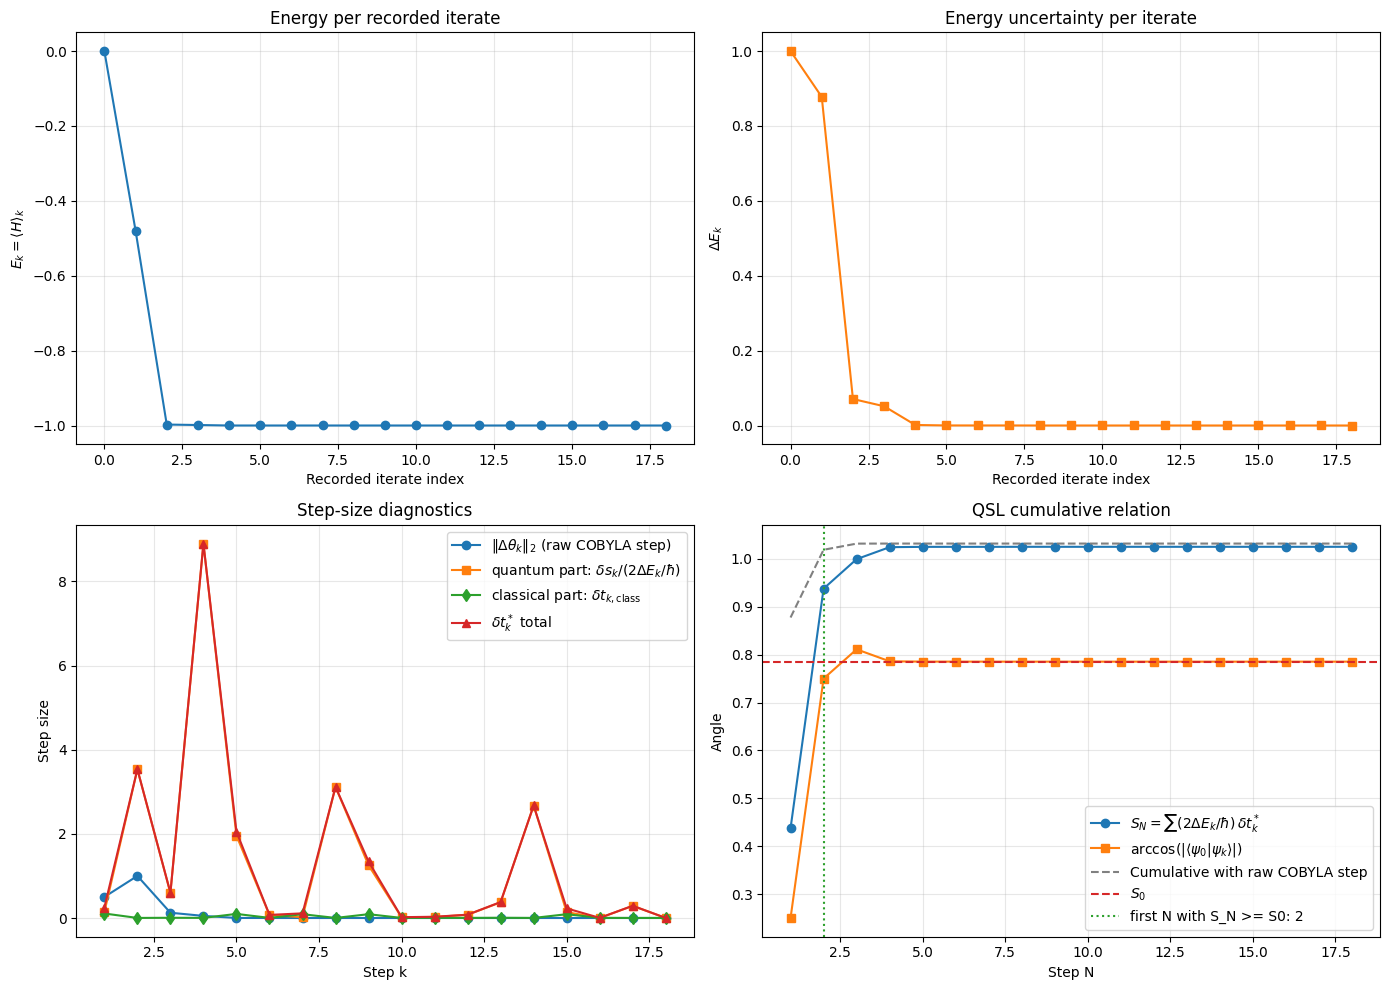

In [5]:
iter_idx = np.arange(len(energies))
finite_dt_star = np.where(np.isfinite(dt_star), dt_star, np.nan)
finite_dt_star_quantum = np.where(np.isfinite(dt_star_quantum), dt_star_quantum, np.nan)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Energy trajectory
axes[0, 0].plot(iter_idx, energies, marker="o", linewidth=1.5)
axes[0, 0].set_title("Energy per recorded iterate")
axes[0, 0].set_xlabel("Recorded iterate index")
axes[0, 0].set_ylabel(r"$E_k = \langle H \rangle_k$")
axes[0, 0].grid(True, alpha=0.3)

# Energy uncertainty
axes[0, 1].plot(iter_idx, deltaE, marker="s", color="tab:orange", linewidth=1.5)
axes[0, 1].set_title("Energy uncertainty per iterate")
axes[0, 1].set_xlabel("Recorded iterate index")
axes[0, 1].set_ylabel(r"$\Delta E_k$")
axes[0, 1].grid(True, alpha=0.3)

# Step-size diagnostics
axes[1, 0].plot(step_idx, raw_dt, marker="o", label=r"$\|\Delta\theta_k\|_2$ (raw COBYLA step)")
axes[1, 0].plot(step_idx, finite_dt_star_quantum, marker="s", label=r"quantum part: $\delta s_k/(2\Delta E_k/\hbar)$")
axes[1, 0].plot(step_idx, classical_dt, marker="d", label=r"classical part: $\delta t_{k,\mathrm{class}}$")
axes[1, 0].plot(step_idx, finite_dt_star, marker="^", label=r"$\delta t_k^*$ total")
axes[1, 0].set_title("Step-size diagnostics")
axes[1, 0].set_xlabel("Step k")
axes[1, 0].set_ylabel("Step size")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Cumulative QSL checks
axes[1, 1].plot(step_idx, S_N, marker="o", label=r"$S_N = \sum (2\Delta E_k/\hbar)\,\delta t_k^*$")
axes[1, 1].plot(step_idx, geo_prefix, marker="s", label=r"$\arccos(|\langle\psi_0|\psi_k\rangle|)$")
axes[1, 1].plot(step_idx, S_raw, linestyle="--", color="gray", label="Cumulative with raw COBYLA step")
axes[1, 1].axhline(S0, color="tab:red", linestyle="--", linewidth=1.5, label=r"$S_0$")

if N_min is not None:
    axes[1, 1].axvline(N_min, color="tab:green", linestyle=":", linewidth=1.5, label=f"first N with S_N >= S0: {N_min}")

axes[1, 1].set_title("QSL cumulative relation")
axes[1, 1].set_xlabel("Step N")
axes[1, 1].set_ylabel("Angle")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## Reading the Output and Plots

- `delta t*_k` is now computed per iteration as `quantum part + classical optimization part`.
- `dt_class` in the table/plot is measured for each iteration separately (no all-iteration averaging).
- `Relation S_N >= S0 at final iterate = True` confirms the QSL inequality for the final optimized state.
- `Smallest N with S_N >= S0` is the first iteration where the cumulative bound reaches the target angle.
